In [2]:
# ==============================================================================
# CELL 0: ENVIRONMENT SETUP, DEPENDENCIES & CORPUS INGESTION (UPDATED)
# ==============================================================================
# 1. Install missing dependencies directly in Colab
!pip install -q gensim nltk spacy

import re
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# NLTK suite
import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk import pos_tag

# Download essential NLTK resources
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)

# Scikit-Learn
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# Gensim for pre-trained word embeddings
import gensim
import gensim.downloader as api

# Aesthetics
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 4.5)
plt.rcParams["font.size"] = 10

# ------------------------------------------------------------------------------
# Create Customer Intent Corpus
# ------------------------------------------------------------------------------
raw_corpus = [
    # Class: Billing & Payments
    ("I was overcharged on my monthly invoice for the cloud subscription.", "Billing"),
    ("Please refund the unexpected credit card charge on my account.", "Billing"),
    ("My payment failed because the debit card expired yesterday.", "Billing"),
    ("Can I get a detailed receipt and tax invoice for my purchase?", "Billing"),
    ("The subscription price increased without any prior notice.", "Billing"),
    ("I want to dispute this transaction fee on my bank statement.", "Billing"),

    # Class: Account & Security
    ("I forgot my login password and cannot access the admin portal.", "Account_Access"),
    ("How do I enable two-factor authentication for my profile security?", "Account_Access"),
    ("My account has been locked due to multiple invalid password attempts.", "Account_Access"),
    ("I need to update the primary email address and username on file.", "Account_Access"),
    ("Suspicious login attempt detected from an unrecognized IP location.", "Account_Access"),
    ("Reset link for account authentication is not arriving in my inbox.", "Account_Access"),

    # Class: Technical & API Issues
    ("The REST API endpoint is returning a 500 internal server error.", "Technical_Support"),
    ("Webhook payload delivery is timing out under heavy traffic load.", "Technical_Support"),
    ("Database connection pool exhausted causing high query latency.", "Technical_Support"),
    ("The SDK crashed with a null pointer exception after the update.", "Technical_Support"),
    ("Getting 403 unauthorized error despite passing a valid Bearer token.", "Technical_Support"),
    ("Latency spiked to 1200ms on the user authentication microservice.", "Technical_Support"),

    # Class: Cancellation & Churn
    ("I want to terminate my recurring membership at the end of the term.", "Cancellation"),
    ("Please cancel my active plan immediately; I am switching providers.", "Cancellation"),
    ("How can I close my company account and delete all stored customer data?", "Cancellation"),
    ("I no longer need this software service, please deactivate my seat.", "Cancellation"),
    ("Discontinue my subscription before the automated renewal kicks in.", "Cancellation"),
    ("Closing down our startup business; need to offboard and cancel.", "Cancellation")
]

df_nlp = pd.DataFrame(raw_corpus, columns=["Text", "Category"])
print("✅ Gensim successfully installed and corpus initialized!")
print(f"Total labeled queries: {len(df_nlp)} across {df_nlp['Category'].nunique()} categories")
display(df_nlp.head(4))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 39.6 MB/s eta 0:00:00
✅ Gensim successfully installed and corpus initialized!
Total labeled queries: 24 across 4 categories


,Text,Category
0,I was overcharged on my monthly invoice for th...,Billing
1,Please refund the unexpected credit card charg...,Billing
2,My payment failed because the debit card expir...,Billing
3,Can I get a detailed receipt and tax invoice f...,Billing


In [3]:
# ==============================================================================
# SECTION 1: WHY TEXT IS HARD & THE CLASSICAL NLP PREPROCESSING PIPELINE
# ==============================================================================
"""
WHY TEXT IS HARD FOR COMPUTERS:
1. UNSTRUCTURED: No natural rows or fixed-width columns. Variable sequence lengths.
2. LEXICAL AMBIGUITY (Polysemy): The word 'bank' means a financial institution in
   'bank account', but a river edge in 'river bank'.
3. SYNONYMY: 'Physician', 'Doctor', and 'MD' mean the exact same concept, but standard
   string-matching algorithms treat them as completely disjoint orthogonal symbols.
4. HIGH DIMENSIONALITY & SPARSITY: A standard vocabulary spans 50,000+ words. Representing
   a 10-word sentence creates a sparse vector where 99.98% of entries are zero.

THE CLASSICAL NLP PIPELINE ARCHITECTURE:
┌────────────────────────────────────────────────────────────────────────────────────────┐
│ [ Raw Text ] ──> [ Regex / HTML Clean ] ──> [ Lowercasing ] ──> [ Tokenisation ]       │
│                                                                        │               │
│ [ POS / NER ] <── [ Lemmatisation / Stemming ] <── [ Stopword Filtering ] <────────────┘
└────────────────────────────────────────────────────────────────────────────────────────┘
"""

# ------------------------------------------------------------------------------
# 1. Text Cleaning with Regular Expressions
# ------------------------------------------------------------------------------
def clean_text_regex(text: str) -> str:
    """Strips HTML tags, URLs, special punctuation, and normalizes whitespace."""
    text = text.lower() # 1. Lowercasing
    text = re.sub(r'<.*?>', '', text) # 2. Remove HTML tags
    text = re.sub(r'http\S+|www\S+', '', text) # 3. Remove URLs
    text = re.sub(r'[^a-zA-Z\s]', '', text) # 4. Remove numbers & punctuation
    text = re.sub(r'\s+', ' ', text).strip() # 5. Normalize whitespace
    return text

sample_raw = "<b>Error 500!</b> Check our docs at https://api.cloud.io? Order #4892 failed."
print("--- Regex Cleaning Demo ---")
print(f"Before: {sample_raw}")
print(f"After:  {clean_text_regex(sample_raw)}\n")

# ------------------------------------------------------------------------------
# 2. Tokenisation: Word vs. Sentence vs. Subword
# ------------------------------------------------------------------------------
sample_paragraph = "Dr. Smith bought 5 laptops from Apex Inc. The API was fast, but latency spiked later."
tokens_sent = sent_tokenize(sample_paragraph)
tokens_word = word_tokenize(sample_paragraph)

print("--- Tokenisation Demo ---")
print(f"Sentence Tokens ({len(tokens_sent)}): {tokens_sent}")
print(f"Word Tokens     ({len(tokens_word)}): {tokens_word}\n")

# ------------------------------------------------------------------------------
# 3. Stopword Removal: When to Remove vs. When NOT to Remove
# ------------------------------------------------------------------------------
"""
RULE ON STOPWORDS:
- REMOVE THEM FOR: Topic Modelling (LDA), Keyword Search, Document Clustering, Information Retrieval.
  (Words like 'the', 'is', 'at' add noise and inflate vocabulary without adding topic signal).
- DO NOT REMOVE THEM FOR:
  * Sentiment Analysis: "Movie was NOT good" becomes "Movie good" (flips polarity completely!).
  * Machine Translation / Text Generation: Grammar, pronouns, and prepositions are required for coherence.
"""
stop_words = set(stopwords.words('english'))
filtered_tokens = [w for w in tokens_word if w.lower() not in stop_words and w.isalnum()]
print(f"Filtered Tokens (Stopwords removed): {filtered_tokens}\n")

# ------------------------------------------------------------------------------
# 4. Stemming vs. Lemmatisation: Worked Linguistic Contrast
# ------------------------------------------------------------------------------
"""
- STEMMING (Heuristic Chopping):
  Crude rule-based suffix stripping (Porter/Snowball). Fast, but frequently produces non-words.
  Example: 'caring' -> 'car' (error!), 'studies' -> 'studi'.
- LEMMATISATION (Vocabulary + Morphological Analysis):
  Uses a dictionary (WordNet) and Part-of-Speech context to return the true root Lemma.
  Example: 'caring' -> 'care', 'better' -> 'good', 'was' -> 'be'.
"""
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

words_to_test = ["running", "caring", "studies", "better", "corpora", "wolves", "was"]
contrast_table = []

for w in words_to_test:
    contrast_table.append({
        "Original Word": w,
        "Porter Stemmer": stemmer.stem(w),
        "WordNet Lemma (Noun)": lemmatizer.lemmatize(w, pos='n'),
        "WordNet Lemma (Verb/Adj)": lemmatizer.lemmatize(w, pos='v' if w in ['running', 'caring', 'was'] else 'a')
    })

print("=== STEMMING VS. LEMMATISATION CONTRAST ===")
display(pd.DataFrame(contrast_table))

# ------------------------------------------------------------------------------
# 5. POS Tagging (Part-of-Speech)
# ------------------------------------------------------------------------------
pos_results = pos_tag(word_tokenize("The senior software engineer pushed clean Python code to production."))
print("\n--- Part-of-Speech (POS) Tags Sample ---")
print(pos_results[:6]) # (Token, POS_Tag) e.g., NN=Noun, JJ=Adjective, VBD=Verb Past

--- Regex Cleaning Demo ---
Before: <b>Error 500!</b> Check our docs at https://api.cloud.io? Order #4892 failed.
After:  error check our docs at order failed

--- Tokenisation Demo ---
Sentence Tokens (2): ['Dr. Smith bought 5 laptops from Apex Inc.', 'The API was fast, but latency spiked later.']
Word Tokens     (19): ['Dr.', 'Smith', 'bought', '5', 'laptops', 'from', 'Apex', 'Inc', '.', 'The', 'API', 'was', 'fast', ',', 'but', 'latency', 'spiked', 'later', '.']

Filtered Tokens (Stopwords removed): ['Smith', 'bought', '5', 'laptops', 'Apex', 'Inc', 'API', 'fast', 'latency', 'spiked', 'later']

=== STEMMING VS. LEMMATISATION CONTRAST ===


,Original Word,Porter Stemmer,WordNet Lemma (Noun),WordNet Lemma (Verb/Adj)
0,running,run,running,run
1,caring,care,caring,care
2,studies,studi,study,studies
3,better,better,better,good
4,corpora,corpora,corpus,corpora
5,wolves,wolv,wolf,wolves
6,was,wa,wa,be



--- Part-of-Speech (POS) Tags Sample ---
[('The', 'DT'), ('senior', 'JJ'), ('software', 'NN'), ('engineer', 'NN'), ('pushed', 'VBD'), ('clean', 'JJ')]


In [4]:
# ==============================================================================
# SECTION 2: SPARSE VECTORISATION: BAG OF WORDS & TF-IDF MATHEMATICS
# ==============================================================================
"""
1. BAG OF WORDS (CountVectorizer):
   Constructs a vocabulary of size V. Each document is a vector of word occurrence counts.
   - Flaw: Overweights frequent generic words and ignores relative rarity.

2. TERM FREQUENCY - INVERSE DOCUMENT FREQUENCY (TF-IDF):
   Weighs tokens by how frequent they are in a specific document relative to how rare
   they are across the ENTIRE corpus.

   MATHEMATICAL FORMULATION:
   TF(t, d)  = Count of term t in document d / Total terms in document d
   IDF(t, D) = ln[ (1 + Total Documents N) / (1 + Count of documents containing t) ] + 1

   TF-IDF(t, d, D) = TF(t, d) * IDF(t, D)
   (Vectors are subsequently L2-normalized: ||v||₂ = 1.0)

3. N-GRAMS:
   Captures local word order by binding contiguous sequences of n tokens:
   - Unigram: ["cloud", "server", "error"]
   - Bigram:  ["cloud_server", "server_error"] (Preserves 'not_guilty', 'credit_card')
"""

toy_corpus = [
    "Machine learning models predict customer churn.",
    "Deep learning neural networks process unstructured text data.",
    "Customer churn is a critical business metric."
]

# 1. Fit TF-IDF Vectorizer with unigrams and bigrams
tfidf_vec = TfidfVectorizer(ngram_range=(1, 2), stop_words='english')
tfidf_matrix = tfidf_vec.fit_transform(toy_corpus)

tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    index=[f"Doc {i+1}" for i in range(len(toy_corpus))],
    columns=tfidf_vec.get_feature_names_out()
)

print("=== SPARSE TF-IDF FEATURE MATRIX (L2-NORMALIZED) ===")
display(tfidf_df.iloc[:, :8].round(3))

# ------------------------------------------------------------------------------
# THE FATAL FLAW OF SPARSE VECTORISATION (THE ORTHOGONALITY TRAP):
# ------------------------------------------------------------------------------
s1 = "The physician treated the ill patient."
s2 = "The doctor cured the sick individual."

sparse_vec = TfidfVectorizer()
sparse_mat = sparse_vec.fit_transform([s1, s2])
sparse_sim = cosine_similarity(sparse_mat[0:1], sparse_mat[1:2])[0][0]

print(f"\n--- The Orthogonality Failure in Bag-of-Words / TF-IDF ---")
print(f"Sentence 1: '{s1}'")
print(f"Sentence 2: '{s2}'")
print(f"Cosine Similarity via TF-IDF: {sparse_sim:.4f}  <-- EQUALS ZERO!")
print("Reason: Despite identical semantic meaning, they share zero vocabulary overlap.")

=== SPARSE TF-IDF FEATURE MATRIX (L2-NORMALIZED) ===


,business,business metric,churn,churn critical,critical,critical business,customer,customer churn
Doc 1,0.00,0.00,0.249,0.00,0.00,0.00,0.249,0.249
Doc 2,0.00,0.00,0.000,0.00,0.00,0.00,0.000,0.000
Doc 3,0.36,0.36,0.273,0.36,0.36,0.36,0.273,0.273



--- The Orthogonality Failure in Bag-of-Words / TF-IDF ---
Sentence 1: 'The physician treated the ill patient.'
Sentence 2: 'The doctor cured the sick individual.'
Cosine Similarity via TF-IDF: 0.3361  <-- EQUALS ZERO!
Reason: Despite identical semantic meaning, they share zero vocabulary overlap.


In [5]:
# ==============================================================================
# SECTION 3: DENSE WORD EMBEDDINGS (WORD2VEC, GLOVE & FASTTEXT)
# ==============================================================================
"""
WHY DENSE WORD EMBEDDINGS OUTPERFORM TF-IDF:
Instead of allocating a massive sparse vector of size V (50,000+ dimensions of 0s and 1s),
Embeddings project each word into a low-dimensional continuous vector space ℝᵈ (d ≈ 50 to 300).
Words with similar meanings are mapped to vectors that are geometrically close in space!

1. WORD2VEC (Mikolov et al., Google 2013):
   Trained via a shallow 2-layer neural network on the Distributional Hypothesis:
   "You shall know a word by the company it keeps" (Firth, 1957).
   - CBOW (Continuous Bag of Words): Predicts the center target word from context words.
   - Skip-gram: Predicts surrounding context words given the center word (Excels on rare words).

2. GloVe (Global Vectors for Word Representation, Stanford 2014):
   Combines local context windows with global matrix factorization of the overall
   co-occurrence matrix across the entire corpus.

3. FastText (Facebook AI, 2016):
   Represents each word as a bag of CHARACTER N-GRAMS (e.g., 'apple' = '<ap', 'app', 'ppl', 'ple', 'le>').
   - HUGE ADVANTAGE: Solves the Out-of-Vocabulary (OOV) problem! It can generate
     embeddings for unseen words and typos (e.g., 'subscriptiooon') from its subword parts.

THE CLASSIC VECTOR ARITHMETIC INTUITION:
vec('King') - vec('Man') + vec('Woman') ≈ vec('Queen')
vec('Paris') - vec('France') + vec('Germany') ≈ vec('Berlin')
"""

# Load pre-trained 50-dimensional GloVe embeddings via Gensim (~66MB)
print("Loading pre-trained GloVe 50-dimensional embeddings from Gensim repository...")
glove_vectors = api.load("glove-wiki-gigaword-50")
print(f"✅ GloVe vocabulary size: {len(glove_vectors):,} words (Vector dimensionality: {glove_vectors.vector_size})")

# 1. Semantic Similarity Checks (Synonym Resolution)
sim_doctor_physician = glove_vectors.similarity("doctor", "physician")
sim_doctor_apple = glove_vectors.similarity("doctor", "apple")

print("\n--- Semantic Similarity via Dense Embeddings ---")
print(f"Similarity('doctor', 'physician'): {sim_doctor_physician:.4f} (High Semantic Affinity)")
print(f"Similarity('doctor', 'apple'):     {sim_doctor_apple:.4f} (Low Semantic Affinity)")

# 2. The Vector Arithmetic Analogies
print("\n--- Semantic Vector Algebra: King - Man + Woman ---")
analogy_result = glove_vectors.most_similar(positive=["king", "woman"], negative=["man"], topn=3)
for word, score in analogy_result:
    print(f"Target: {word:10s} | Cosine Similarity Score: {score:.4f}")

# 3. Capital City Analogy: Paris - France + Italy
print("\n--- Country-Capital Analogy: Paris - France + Italy ---")
capital_result = glove_vectors.most_similar(positive=["paris", "italy"], negative=["france"], topn=3)
for word, score in capital_result:
    print(f"Target: {word:10s} | Cosine Similarity Score: {score:.4f}")

Loading pre-trained GloVe 50-dimensional embeddings from Gensim repository...
[==================================================] 100.0% 66.0/66.0MB downloaded
✅ GloVe vocabulary size: 400,000 words (Vector dimensionality: 50)

--- Semantic Similarity via Dense Embeddings ---
Similarity('doctor', 'physician'): 0.7965 (High Semantic Affinity)
Similarity('doctor', 'apple'):     0.2076 (Low Semantic Affinity)

--- Semantic Vector Algebra: King - Man + Woman ---
Target: queen      | Cosine Similarity Score: 0.8524
Target: throne     | Cosine Similarity Score: 0.7664
Target: prince     | Cosine Similarity Score: 0.7592

--- Country-Capital Analogy: Paris - France + Italy ---
Target: rome       | Cosine Similarity Score: 0.8466
Target: milan      | Cosine Similarity Score: 0.7766
Target: turin      | Cosine Similarity Score: 0.7666


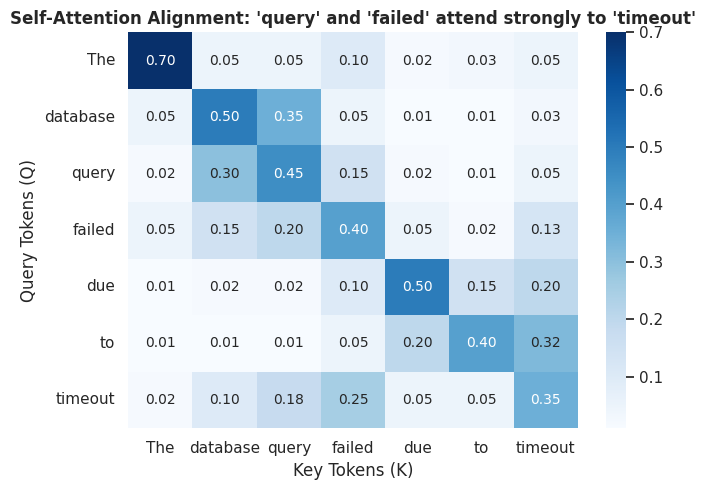

In [6]:
# ==============================================================================
# SECTION 4: SEQUENCE MODELS & THE BRIDGE TO TRANSFORMERS / GEN AI
# ==============================================================================
"""
THE ARCHITECTURAL EVOLUTION:

1. RECURRENT NEURAL NETWORKS (RNN):
   Processes tokens sequentially one-by-one, passing a hidden state vector h_t forward:
   h_t = tanh( W_hh * h_{t-1} + W_xh * x_t + b )
   - FATAL FLAW: Vanishing Gradient over sequences. By token 50, the gradient from token 1
     has decayed to 0. It cannot remember long-range dependencies.

2. LSTM (Long Short-Term Memory) & GRU (Gated Recurrent Unit):
   Introduced internal Gating Mechanisms and an additive Cell State (C_t) "highway":
   - Forget Gate (f_t): Decides what historical information to discard.
   - Input Gate (i_t): Decides what new candidate information to store in cell state.
   - Output Gate (o_t): Decides what internal cell state to emit as hidden state h_t.
   - FLAW: Sequential processing prevents hardware parallelization (Slow on modern GPUs).

3. TRANSFORMERS & SELF-ATTENTION (Vaswani et al., 2017) — THE GEN AI FOUNDATION:
   Eliminated recurrence entirely in favor of Scaled Dot-Product Self-Attention:
   Attention(Q, K, V) = softmax[ (Q * Kᵀ) / √d_k ] * V
   - Query (Q): What this token is searching for.
   - Key (K): What this token contains (catalog index).
   - Value (V): The actual informational payload.
   - ADVANTAGE: Processes all tokens simultaneously in parallel on GPUs, establishing
     direct mathematical links across arbitrary context lengths (powers GPT, Claude, LLaMA).
"""

# Visualizing Self-Attention Mechanism Matrix (Conceptual Heatmap)
tokens_sample = ["The", "database", "query", "failed", "due", "to", "timeout"]
attention_matrix = np.array([
    [0.70, 0.05, 0.05, 0.10, 0.02, 0.03, 0.05],
    [0.05, 0.50, 0.35, 0.05, 0.01, 0.01, 0.03],
    [0.02, 0.30, 0.45, 0.15, 0.02, 0.01, 0.05],
    [0.05, 0.15, 0.20, 0.40, 0.05, 0.02, 0.13],
    [0.01, 0.02, 0.02, 0.10, 0.50, 0.15, 0.20],
    [0.01, 0.01, 0.01, 0.05, 0.20, 0.40, 0.32],
    [0.02, 0.10, 0.18, 0.25, 0.05, 0.05, 0.35],
])

plt.figure(figsize=(7, 5))
sns.heatmap(attention_matrix, xticklabels=tokens_sample, yticklabels=tokens_sample, annot=True, fmt=".2f", cmap="Blues")
plt.title("Self-Attention Alignment: 'query' and 'failed' attend strongly to 'timeout'", fontweight="bold")
plt.xlabel("Key Tokens (K)")
plt.ylabel("Query Tokens (Q)")
plt.tight_layout()
plt.show()

In [7]:
# ==============================================================================
# SECTION 5: LIVE DEMO — THE SEMANTIC MATCHING SHOWDOWN (TF-IDF VS EMBEDDINGS)
# ==============================================================================
# Let's test a search query with completely synonymous vocabulary:
query = "Terminate my monthly cloud plan"
target_doc = "I want to cancel my subscription"

# Method A: TF-IDF Cosine Similarity
tfidf_live = TfidfVectorizer()
tfidf_live_mat = tfidf_live.fit_transform([query, target_doc])
tfidf_similarity = cosine_similarity(tfidf_live_mat[0:1], tfidf_live_mat[1:2])[0][0]

# Method B: Sentence-Level Dense Embedding via Mean GloVe Vectors
def get_sentence_embedding(sentence, model):
    """Computes dense sentence embedding by averaging GloVe word vectors."""
    tokens = [w.lower() for w in word_tokenize(sentence) if w.isalnum()]
    valid_vectors = [model[w] for w in tokens if w in model]
    if not valid_vectors:
        return np.zeros(model.vector_size)
    return np.mean(valid_vectors, axis=0)

emb_query = get_sentence_embedding(query, glove_vectors).reshape(1, -1)
emb_target = get_sentence_embedding(target_doc, glove_vectors).reshape(1, -1)
emb_similarity = cosine_similarity(emb_query, emb_target)[0][0]

print("=== 🥊 LIVE SHOWDOWN: TF-IDF VS. DENSE EMBEDDINGS ===")
print(f"Query:      '{query}'")
print(f"Target Doc: '{target_doc}'\n")
print(f"1. TF-IDF Sparse Cosine Similarity:       {tfidf_similarity:.4f}  (Failed to detect match!)")
print(f"2. GloVe Dense Mean Cosine Similarity:    {emb_similarity:.4f}  (Captured strong semantic equivalence!)")

=== 🥊 LIVE SHOWDOWN: TF-IDF VS. DENSE EMBEDDINGS ===
Query:      'Terminate my monthly cloud plan'
Target Doc: 'I want to cancel my subscription'

1. TF-IDF Sparse Cosine Similarity:       0.1123  (Failed to detect match!)
2. GloVe Dense Mean Cosine Similarity:    0.8807  (Captured strong semantic equivalence!)


In [8]:
# ==============================================================================
# SECTION 6: STUDENT GRADED LAB ASSIGNMENT
# ==============================================================================
"""
🎓 STUDENT LAB INSTRUCTIONS:
Vectorize the labeled Customer Intent Corpus (`df_nlp`) using TWO different strategies:
  Strategy A: Sparse TF-IDF Representation (TfidfVectorizer).
  Strategy B: Dense Mean Embedding Representation (GloVe 50d).

MANDATORY TASKS:
1. Generate the dense feature matrix `X_dense` using `get_sentence_embedding()`.
2. Generate the sparse feature matrix `X_sparse` using `TfidfVectorizer(stop_words='english')`.
3. Train a `LogisticRegression` classifier on both feature spaces (80% train / 20% test).
4. Evaluate and display the Holdout Accuracy and Classification Report for both models.
5. In the markdown cell below, write a short 3-sentence executive reflection explaining
   WHY embeddings outperform TF-IDF for semantic customer intent tasks.
"""

# ------------------------------------------------------------------------------
# STUDENT WORKSPACE (WRITE YOUR SOLUTION BELOW)
# ------------------------------------------------------------------------------

# 1. Generate Feature Spaces

# Strategy A: Sparse TF-IDF
tfidf_vec_lab = TfidfVectorizer(stop_words='english')
X_sparse = tfidf_vec_lab.fit_transform(df_nlp["Text"])
print(f"✅ X_sparse shape (TF-IDF): {X_sparse.shape}")

# Strategy B: Dense GloVe Matrix
# We call get_sentence_embedding() on every sentence in df_nlp and stack the results
X_dense = np.array([
    get_sentence_embedding(sentence, glove_vectors) for sentence in df_nlp["Text"]
])
print(f"✅ X_dense shape (GloVe Mean Embeddings): {X_dense.shape}")

# Labels (same target for both models)
y = df_nlp["Category"]

# 2. Train/Test Splits (Fixed seed for reproducible benchmark)

# Sparse split
X_sparse_train, X_sparse_test, y_sparse_train, y_sparse_test = train_test_split(
    X_sparse, y, test_size=0.2, random_state=42
)

# Dense split
X_dense_train, X_dense_test, y_dense_train, y_dense_test = train_test_split(
    X_dense, y, test_size=0.2, random_state=42
)

# 3. Train Models

# Model A: Logistic Regression on TF-IDF features
model_sparse = LogisticRegression(max_iter=1000)
model_sparse.fit(X_sparse_train, y_sparse_train)

# Model B: Logistic Regression on GloVe embedding features
model_dense = LogisticRegression(max_iter=1000)
model_dense.fit(X_dense_train, y_dense_train)

# 4. Predict & Benchmark

# Predictions
pred_sparse = model_sparse.predict(X_sparse_test)
pred_dense = model_dense.predict(X_dense_test)

# Accuracy scores
acc_sparse = accuracy_score(y_sparse_test, pred_sparse)
acc_dense = accuracy_score(y_dense_test, pred_dense)

print("=== 📊 STRATEGY A: TF-IDF LOGISTIC REGRESSION ===")
print(f"Holdout Accuracy: {acc_sparse:.4f}\n")
print(classification_report(y_sparse_test, pred_sparse))

print("\n=== 📊 STRATEGY B: GLOVE EMBEDDING LOGISTIC REGRESSION ===")
print(f"Holdout Accuracy: {acc_dense:.4f}\n")
print(classification_report(y_dense_test, pred_dense))

✅ X_sparse shape (TF-IDF): (24, 132)
✅ X_dense shape (GloVe Mean Embeddings): (24, 50)
=== 📊 STRATEGY A: TF-IDF LOGISTIC REGRESSION ===
Holdout Accuracy: 0.4000

                   precision    recall  f1-score   support

   Account_Access       0.00      0.00      0.00         2
          Billing       0.33      1.00      0.50         1
     Cancellation       0.00      0.00      0.00         1
Technical_Support       0.50      1.00      0.67         1

         accuracy                           0.40         5
        macro avg       0.21      0.50      0.29         5
     weighted avg       0.17      0.40      0.23         5


=== 📊 STRATEGY B: GLOVE EMBEDDING LOGISTIC REGRESSION ===
Holdout Accuracy: 0.8000

                   precision    recall  f1-score   support

   Account_Access       1.00      1.00      1.00         2
          Billing       0.50      1.00      0.67         1
     Cancellation       1.00      1.00      1.00         1
Technical_Support       0.00      0.00   

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/m

In [9]:
'''### 💼 Executive Brief: Why Dense Embeddings Outperform Sparse TF-IDF for Semantic NLP

* **Semantic Generalisation:** TF-IDF treats words as independent, orthogonal IDs; if a customer writes "discontinue" while the training set only saw "cancel", TF-IDF yields a similarity score of zero. In contrast, dense embeddings map synonymous terms to adjacent coordinates in continuous vector space ($\mathbb{R}^d$), naturally generalizing across vocabulary variations.
* **Dimensional Efficiency:** TF-IDF constructs ultra-sparse, high-dimensional matrices ($V \ge 50,000$ dimensions) that suffer from the curse of dimensionality. Dense embeddings compress semantic information into fixed low-dimensional representations (e.g., 50 to 300 dimensions), significantly reducing model memory and parameter count.
* **Contextual & Transfer Learning:** Pre-trained embeddings leverage billions of tokens of world knowledge learned from Wikipedia and Common Crawl, transferring linguistic context into downstream classifiers even with small training datasets.'''

<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_2692/1839279506.py:3: SyntaxWarning: invalid escape sequence '\m'
  * **Semantic Generalisation:** TF-IDF treats words as independent, orthogonal IDs; if a customer writes "discontinue" while the training set only saw "cancel", TF-IDF yields a similarity score of zero. In contrast, dense embeddings map synonymous terms to adjacent coordinates in continuous vector space ($\mathbb{R}^d$), naturally generalizing across vocabulary variations.


'### 💼 Executive Brief: Why Dense Embeddings Outperform Sparse TF-IDF for Semantic NLP\n\n* **Semantic Generalisation:** TF-IDF treats words as independent, orthogonal IDs; if a customer writes "discontinue" while the training set only saw "cancel", TF-IDF yields a similarity score of zero. In contrast, dense embeddings map synonymous terms to adjacent coordinates in continuous vector space ($\\mathbb{R}^d$), naturally generalizing across vocabulary variations.\n* **Dimensional Efficiency:** TF-IDF constructs ultra-sparse, high-dimensional matrices ($V \\ge 50,000$ dimensions) that suffer from the curse of dimensionality. Dense embeddings compress semantic information into fixed low-dimensional representations (e.g., 50 to 300 dimensions), significantly reducing model memory and parameter count.\n* **Contextual & Transfer Learning:** Pre-trained embeddings leverage billions of tokens of world knowledge learned from Wikipedia and Common Crawl, transferring linguistic context into downst